In [2]:
import sys
import numpy as np
import anndata as ad
import pandas as pd
import polars as pl

import src as scit

In [3]:
cttag = ad.read_h5ad('private/data/clean_method/cttag_wt_inferred.h5ad')
#rna   = ad.read_h5ad('private/data/glue/rna_2025_hmm.h5ad')

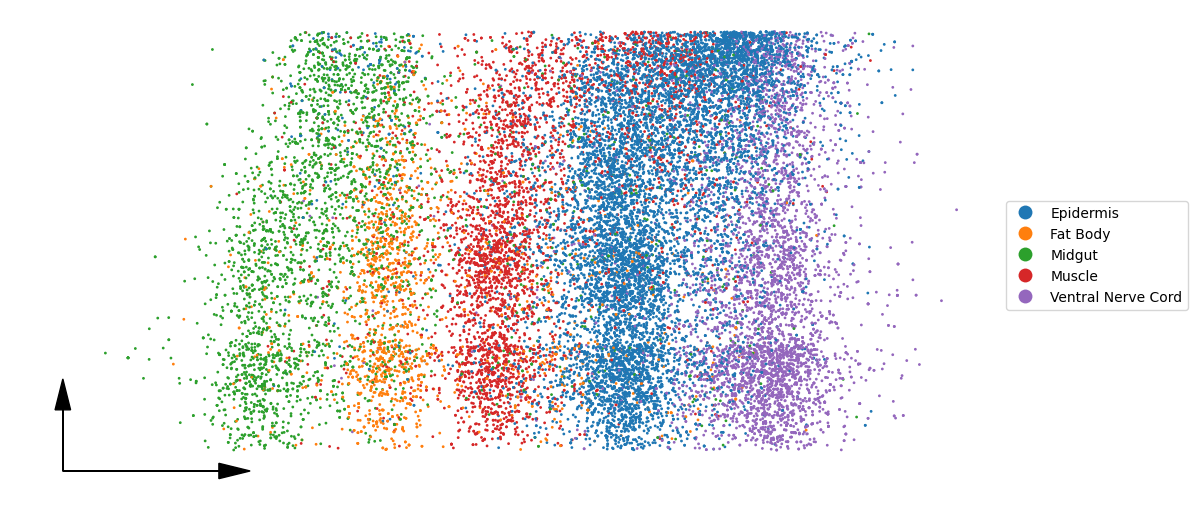

In [4]:
scit.pl.embedding2d(cttag, 'X_landscape', 'label', size=1)

In [5]:
lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=True,
    log_transform=False,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=True,
    log_transform=False,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
# lc_rna = scit.tl.make_layer_config(
#     'rna',
#     normalize_with_obs_counts=True,
#     log_transform=True,
#     feature_active_threshold=2.7,
#     feature_names=rna.var_names
# )

In [6]:
cttag.obs['ptime'] = -cttag.obsm['X_landscape'][:,1]
# rna.obs['ptime'] = -rna.obsm['X_landscape'][:,1]
# rna.obs['label'] = rna.obs['label_own']

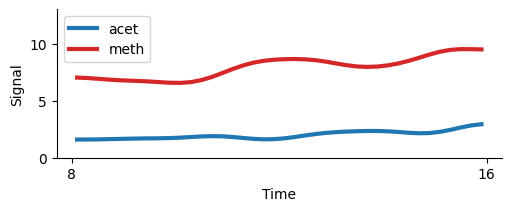

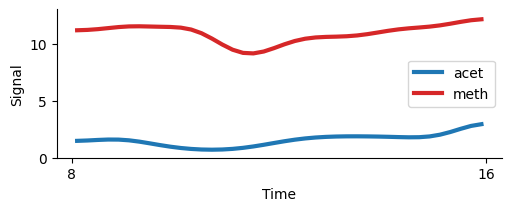

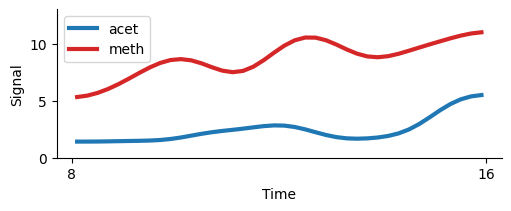

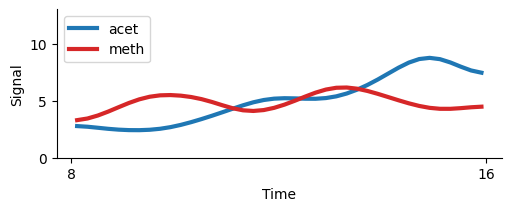

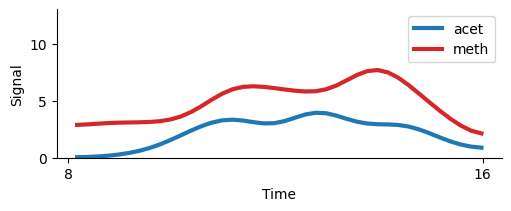

In [14]:
ss={'s': 2, 'alpha': 0.2}
l = dict(
    plot_style='smooth', plot_zeros=False, binsize=0.2, gauss_sigma=3, line_style={'linewidth':3},
    colors=['tab:blue', 'tab:red'], labels=['acet', 'meth'], scatter_style=ss, show=False
)
import matplotlib.pyplot as plt

scit.set_defaults(figsize=(5,2))

def plot_for_ct(gn, scalars, yminmax):
    for ct in cttag.obs['label'].unique():
        fig=scit.adv.pl.time_correlation([cttag, cttag], [lc_acet, lc_meth], 'label', f'{ct}',
                                'ptime', gn, yminmax=yminmax, scalars=scalars, **l)
        
        fig.axes[0].set_xticks([8, 16])
        fig.savefig(f'private/newest/screenshots/{gn}_acet_mul{scalars[0]}_{ct}.pdf')
plot_for_ct('GATAe', [2,1], (0,13))

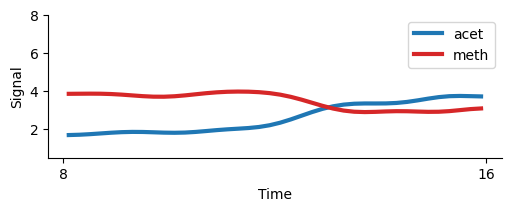

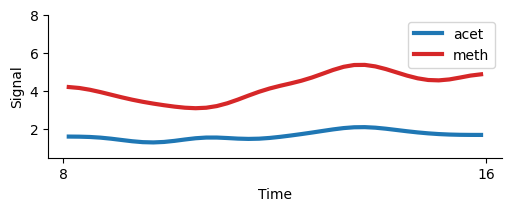

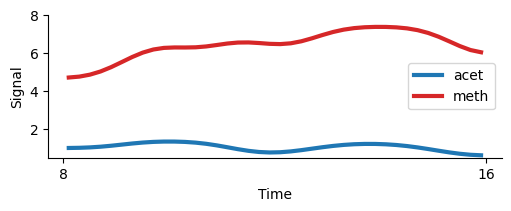

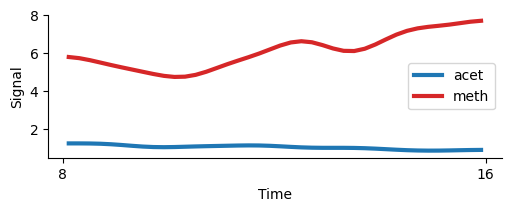

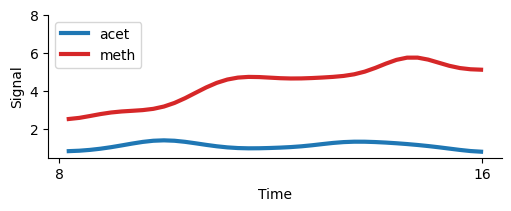

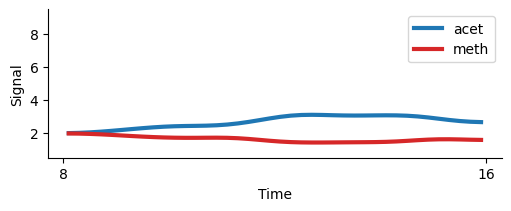

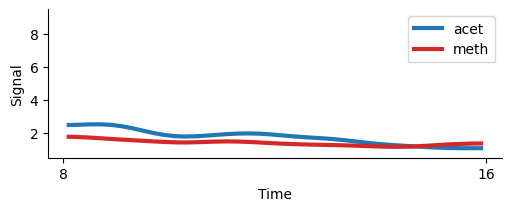

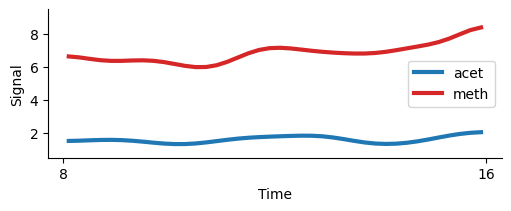

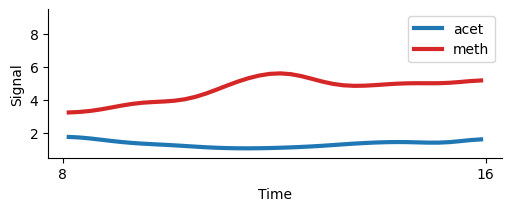

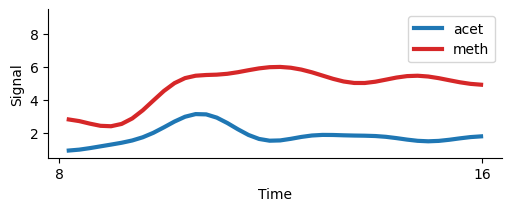

In [ ]:
plot_for_ct('vvl', [1.5,1], (0.5,8))
plot_for_ct('grh', [2,1], (0.5,9.5))

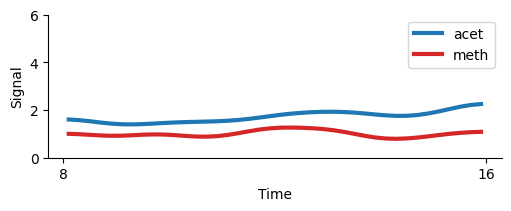

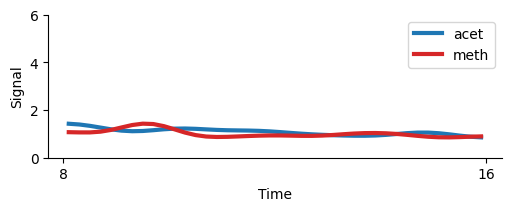

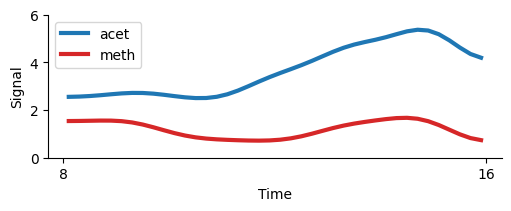

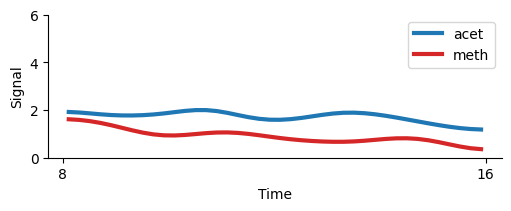

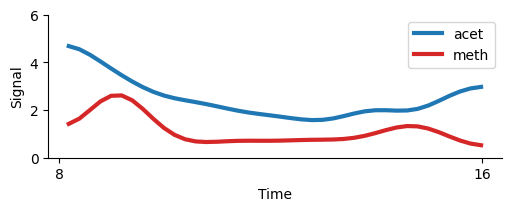

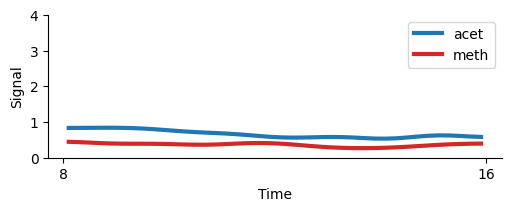

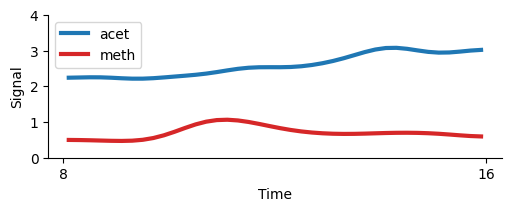

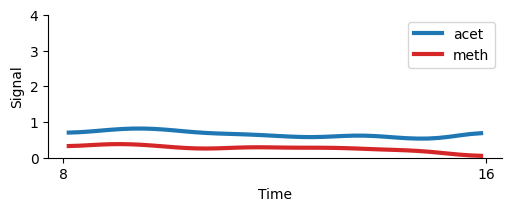

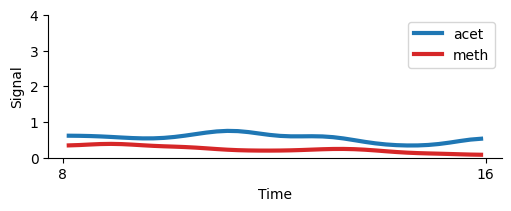

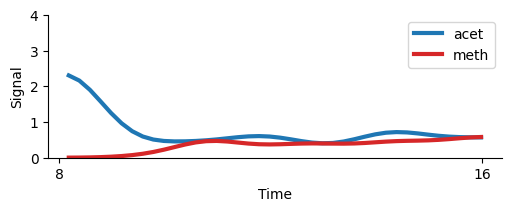

In [18]:
plot_for_ct('Mef2', [1.5,1], (0,6))
plot_for_ct('Oli', [1.5,1], (0,4))

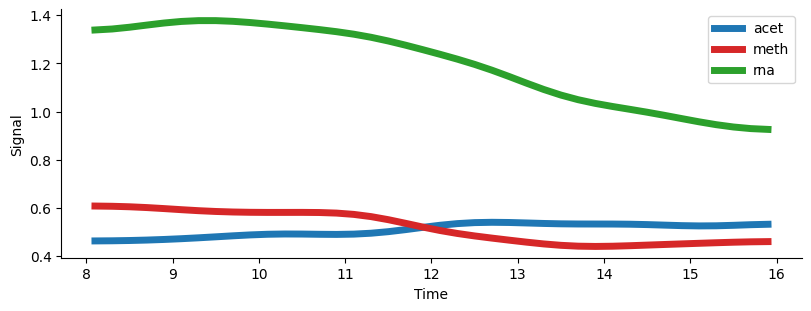

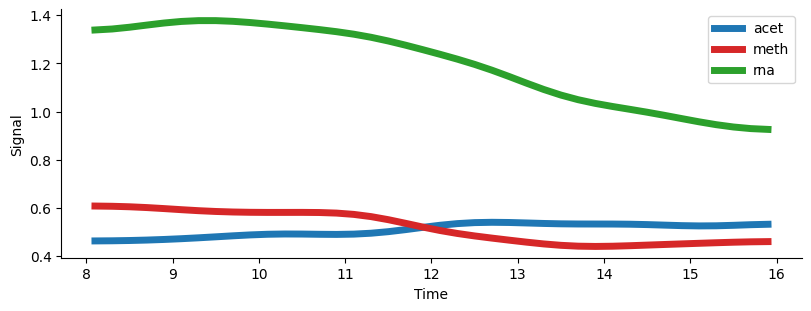

In [8]:
ss={'s': 2, 'alpha': 0.2}
l = dict(
    plot_style='smooth', plot_zeros=False, binsize=0.2, gauss_sigma=3,
    colors=['tab:blue', 'tab:red', 'tab:green'], yminmax=None, labels=['acet', 'meth', 'rna'], scatter_style=ss
)
gn = 'grh'
scit.set_defaults(figsize=(8,3))

#scit.adv.pl.time_correlation([cttag, cttag], [lc_acet, lc_meth], 'label', 'Ventral Nerve Cord',
#                              'ptime', gn, **l)
scit.adv.pl.time_correlation([cttag, cttag, rna], [lc_acet, lc_meth, lc_rna], 'label', 'Epidermis',
                              'ptime', gn, **l)

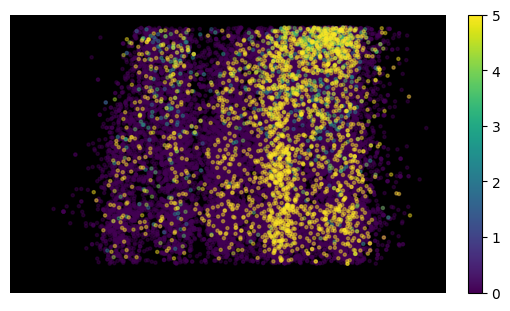

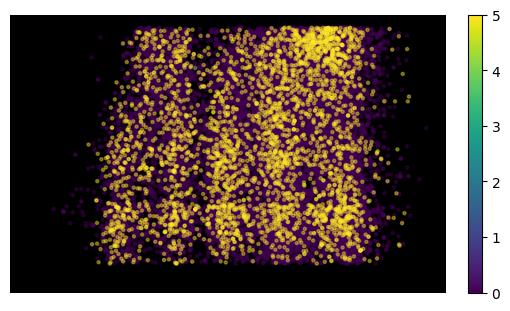

In [ ]:
gn = 'vvl'

scit.set_defaults(figsize=(5,3))
scit.tl.layer_pick_features(cttag, lc_acet, gn)
scit.tl.copy_to_obs(cttag, lc_acet)
scit.pl.embedding2d(cttag, 'X_landscape', 'copied_data', size=5, alpha=0.4, black_background=True, vminmax=(0,5))


scit.tl.layer_pick_features(cttag, lc_meth, gn)
scit.tl.copy_to_obs(cttag, lc_meth)
scit.pl.embedding2d(cttag, 'X_landscape', 'copied_data', size=5, alpha=0.4, black_background=True, vminmax=(0,5))

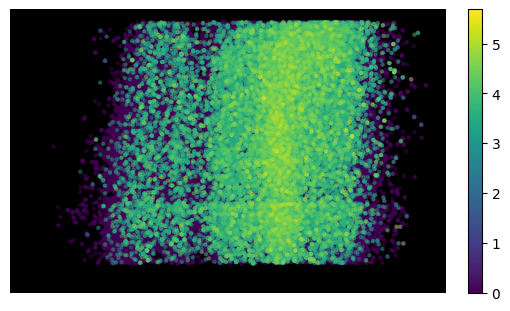

In [32]:
scit.set_defaults(figsize=(5,3))
scit.tl.layer_pick_features(rna, lc_rna, gn)
scit.tl.copy_to_obs(rna, lc_rna)
scit.pl.embedding2d(rna, 'X_landscape', 'copied_data', size=5, alpha=0.4, black_background=True)

In [7]:
lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=True,
    log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=True,
    log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)



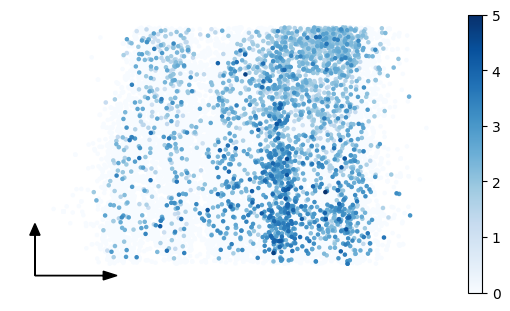

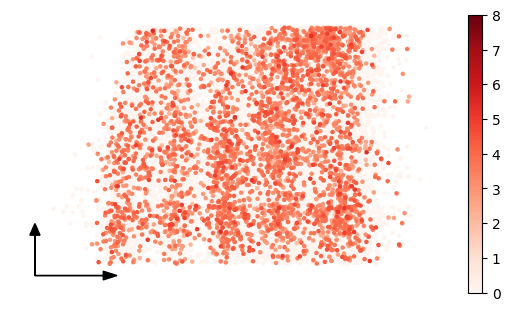

In [12]:
gn = 'vvl'

scit.set_defaults(figsize=(5,3))
scit.tl.layer_pick_features(cttag, lc_acet, gn)
scit.tl.copy_to_obs(cttag, lc_acet)
f=scit.pl.embedding2d(cttag, 'X_landscape', 'copied_data', size=5, alpha=1, black_background=False, cmap='Blues', vminmax=(0,5), show=False)
f.savefig('private/newest/screenshots/vvl_acet_lsc.png', dpi=300)

scit.tl.layer_pick_features(cttag, lc_meth, gn)
scit.tl.copy_to_obs(cttag, lc_meth)
f=scit.pl.embedding2d(cttag, 'X_landscape', 'copied_data', size=5, alpha=1, black_background=False, cmap='Reds', vminmax=(0,8), show=False)
f.savefig('private/newest/screenshots/vvl_meth_lsc.png', dpi=300)